In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-10 15:57:10.121194


# Doublet scoring

Run scrublet after light filtering, on individual samples prior to concatenation.

In [2]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scrublet as scr
import sys
import anndata as ad
import session_info

In [3]:
plt.rcParams['figure.figsize'] = (3,3)

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_01/02_pre-filtered"
scrublet_dir = os.path.join(base_dir, 'scrublet')
output_dir = os.path.join(base_dir, 'data/h5ad/export_01/03_scrublet')

os.makedirs(output_dir, exist_ok=True)

In [5]:
sample_files = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.h5ad')]
adata_list = [sc.read_h5ad(f) for f in sample_files] #sc.read is deprecated

adata_list

[AnnData object with n_obs × n_vars = 21501 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 32284 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_

In [6]:
def run_scrublet(adata_list, scrublet_dir):
    os.makedirs(scrublet_dir, exist_ok=True)

    for i, adata in enumerate(adata_list):
        sample_id = adata.obs['output_id'].unique()[0]
        print(f"Running Scrublet for {sample_id}...")

        # Run Scrublet with expected doublet rate (5% recommended for Xenium)
        scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.05)
        doublet_scores, predicted_doublets = scrub.scrub_doublets(
            min_counts=2, 
            min_cells=3, 
            min_gene_variability_pctl=85, 
            n_prin_comps=30
        )

        # **Auto-set threshold, but provide a backup in case it fails**
        if scrub.threshold_ is not None:
            doublet_threshold = scrub.threshold_
            print(f"Scrublet auto-set threshold for {sample_id}: {doublet_threshold:.3f}")
        else:
            # **Fallback threshold: Use mean + 2*std from simulated doublet scores**
            doublet_threshold = scrub.doublet_scores_sim_.mean() + 2 * scrub.doublet_scores_sim_.std()
            print(f"Warning: Scrublet auto-threshold failed for {sample_id}. Using fallback threshold: {doublet_threshold:.3f}")

        # Apply the determined threshold
        predicted_doublets = scrub.call_doublets(threshold=doublet_threshold)

        # Store results in AnnData object
        adata.obs['doublet_scores'] = doublet_scores
        adata.obs['predicted_doublets'] = predicted_doublets

        # Plot Scrublet score histograms
        plt.figure(figsize=(10, 6))
        sns.histplot(scrub.doublet_scores_obs_, bins=30, color="blue", label="Observed", kde=True)
        sns.histplot(scrub.doublet_scores_sim_, bins=30, color="red", label="Simulated", kde=True)
        plt.axvline(doublet_threshold, color='green', linestyle='--', label=f'Threshold: {doublet_threshold:.3f}')
        plt.title(f'Scrublet Doublet Score Distribution for {sample_id}')
        plt.xlabel('Doublet Score')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

        # Prepare Scrublet DataFrame for this sample
        scrublet_rows = [{
            'Sample_ID': sample_id,
            'Cell_Barcode': barcode,
            'Observed_Score': obs_score,
            'Simulated_Score': sim_score,
            'Doublet_Score': doublet_scores,
            'Predicted_Doublet': pred_doublet
        } for barcode, obs_score, sim_score, pred_doublet in zip(
            adata.obs.index, scrub.doublet_scores_obs_, scrub.doublet_scores_sim_, predicted_doublets
        )]

        # Convert to DataFrame and save per sample
        scrublet_df = pd.DataFrame(scrublet_rows)
        scrublet_csv_path = os.path.join(scrublet_dir, f"{sample_id}_scrublet_results.csv")
        scrublet_df.to_csv(scrublet_csv_path, index=False)

        print(f"Saved Scrublet results for {sample_id} to {scrublet_csv_path}")

Running Scrublet for TMA00304...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 100.0%
Elapsed time: 14.8 seconds
Scrublet auto-set threshold for TMA00304: 0.435
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 100.0%


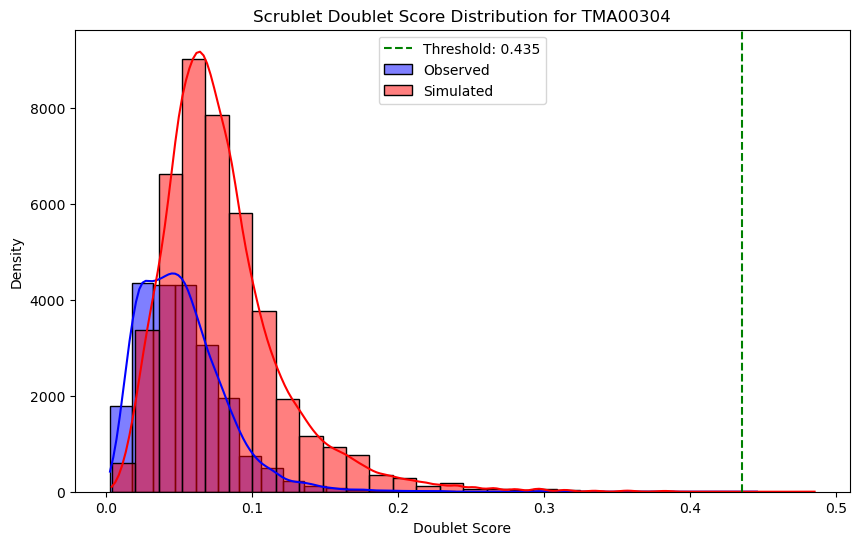

Saved Scrublet results for TMA00304 to /home/workspace/projects/drg/scrublet/TMA00304_scrublet_results.csv
Running Scrublet for TMA00306...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 28.6 seconds
Scrublet auto-set threshold for TMA00306: 0.359
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


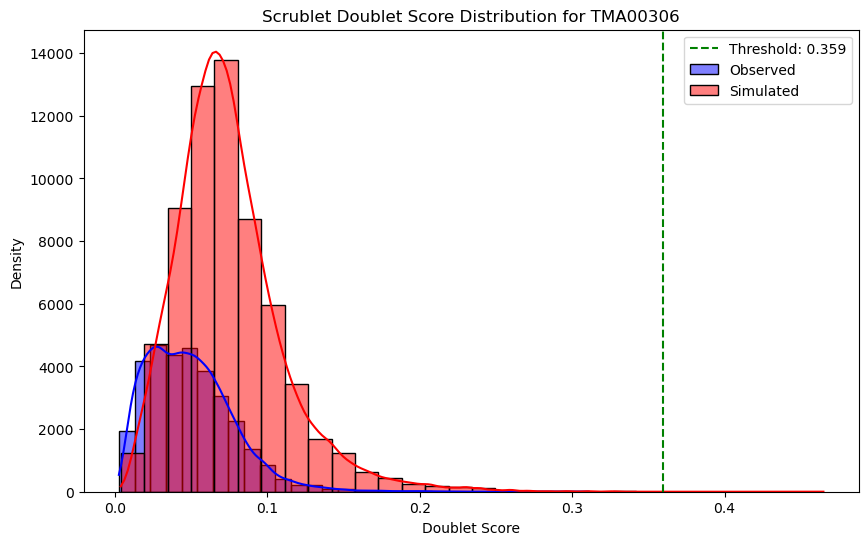

Saved Scrublet results for TMA00306 to /home/workspace/projects/drg/scrublet/TMA00306_scrublet_results.csv
Running Scrublet for TMA00303...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.29
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 10.0%
Elapsed time: 5.5 seconds
Scrublet auto-set threshold for TMA00303: 0.294
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 10.0%


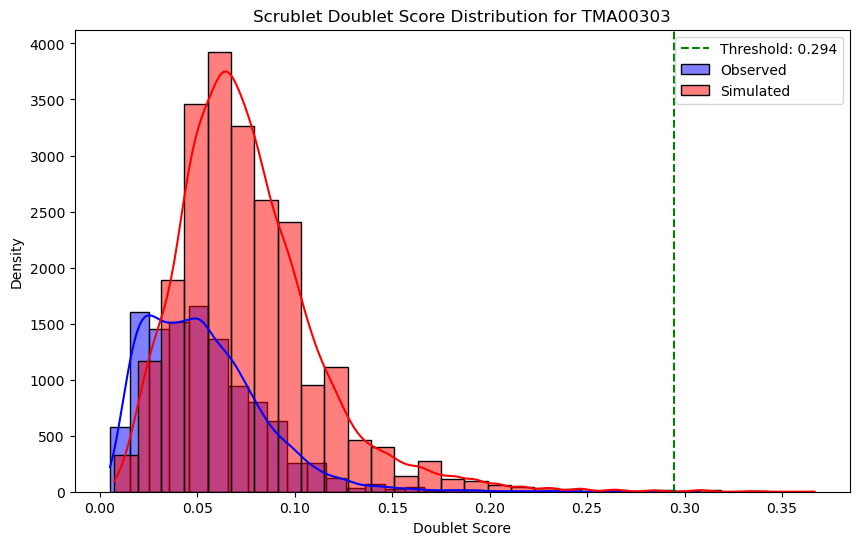

Saved Scrublet results for TMA00303 to /home/workspace/projects/drg/scrublet/TMA00303_scrublet_results.csv
Running Scrublet for TMA00305...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.31
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 29.0 seconds
Scrublet auto-set threshold for TMA00305: 0.307
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


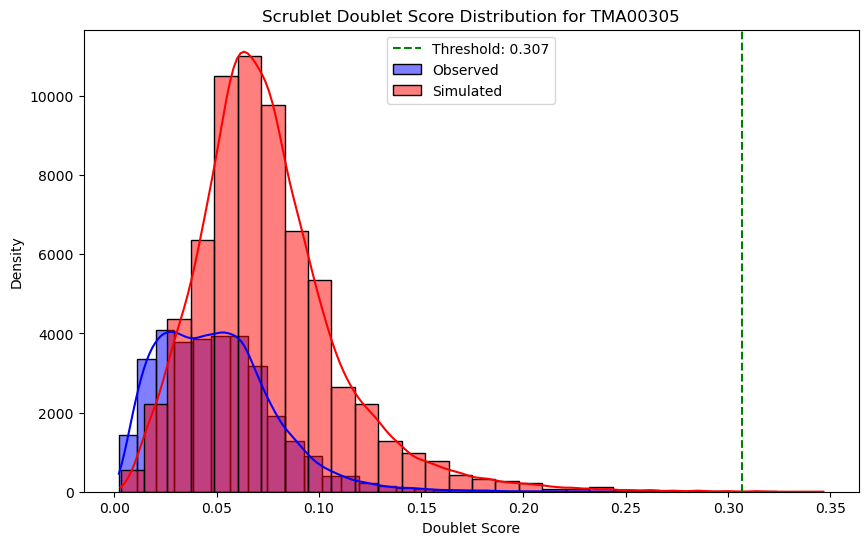

Saved Scrublet results for TMA00305 to /home/workspace/projects/drg/scrublet/TMA00305_scrublet_results.csv


In [7]:
scrublet_result = run_scrublet(adata_list, scrublet_dir)

## Export

In [8]:
for i, adata in enumerate(adata_list):
    sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
    output_file = os.path.join(output_dir, f"{sample_name}.h5ad")
    
    adata.write(output_file)
    print(f"Saved: {output_file}")

Saved: /home/workspace/projects/drg/data/h5ad/export_01/03_scrublet/TMA00304.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/03_scrublet/TMA00306.h5ad


/tmp/ipykernel_4204/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_4204/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_4204/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

Saved: /home/workspace/projects/drg/data/h5ad/export_01/03_scrublet/TMA00303.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/03_scrublet/TMA00305.h5ad


/tmp/ipykernel_4204/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"


## Session info

In [9]:
print('active IDE: sc-sq')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq
active conda environment: sc-scrublet
